# The 5 features we are using is HOG + Color(HSV) + GLCM + LBP + Positional (x,y)

# Feature Building

In [1]:
# === Build features: HOG + Color(HSV) + GLCM + LBP + (x,y) position ===
import os, cv2, numpy as np, pandas as pd
from tqdm import tqdm
from skimage.feature import hog, local_binary_pattern

# robust GLCM import for skimage 0.25+ (fallback for older)
try:
    from skimage.feature.texture import graycomatrix as greycomatrix, graycoprops as greycoprops
except Exception:
    from skimage.feature import greycomatrix, greycoprops

# ---------- Paths ----------
PREPROCESSED_DIR = "/home/pratyush/Desktop/DS_Project/data/preprocessed"
SPLIT_DIR        = "/home/pratyush/Desktop/DS_Project/data/splits"
OUT_DIR          = "/home/pratyush/Desktop/DS_Project/data/features"
SUFFIX           = "hog_color_glcm_lbp_pos"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Grid ----------
GRID_W, GRID_H = 8, 8
TARGET_W, TARGET_H = 800, 600
CELL_W, CELL_H = TARGET_W // GRID_W, TARGET_H // GRID_H  # 100x75
CELL_COLS = [f"c{i:02d}" for i in range(1, 65)]

# ---------- Feature extractors ----------
def feat_hog(gray_cell):
    return hog(gray_cell,
               orientations=9,
               pixels_per_cell=(8, 8),      # keep as in your current run; change to (6,6) only if you want v2
               cells_per_block=(2, 2),
               block_norm="L2-Hys",
               feature_vector=True)

def feat_color_hist(hsv_cell):
    h = cv2.calcHist([hsv_cell],[0],None,[8],[0,180])
    s = cv2.calcHist([hsv_cell],[1],None,[8],[0,256])
    v = cv2.calcHist([hsv_cell],[2],None,[8],[0,256])
    f = np.concatenate([h, s, v]).ravel().astype(np.float32)
    return f / (f.sum() + 1e-6)

def feat_glcm(gray_cell):
    # quantize to 32 levels for robustness on small patches
    g = cv2.normalize(gray_cell, None, 0, 31, cv2.NORM_MINMAX).astype(np.uint8)
    glcm = greycomatrix(g,
                        distances=[1, 2],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=32, symmetric=True, normed=True)
    props = ['contrast','dissimilarity','homogeneity','energy','correlation','ASM']
    return np.array([float(np.mean(greycoprops(glcm, p))) for p in props], dtype=np.float32)

def feat_lbp(gray_cell, P=8, R=1.0):
    # Uniform LBP: values in [0 .. P+1] → P+2 bins
    lbp = local_binary_pattern(gray_cell, P=P, R=R, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, P+3), range=(0, P+2))
    hist = hist.astype(np.float32)
    return hist / (hist.sum() + 1e-6)   # 10-dim for P=8

def extract_features_from_image(img_path, row_labels):
    img = cv2.imread(img_path)
    if img is None:
        print("⚠️ cannot read", img_path); return None, None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    feats, labels, meta = [], [], []
    for r in range(GRID_H):
        for c in range(GRID_W):
            x0, y0 = c*CELL_W, r*CELL_H
            gcell = gray[y0:y0+CELL_H, x0:x0+CELL_W]
            hcell = hsv [y0:y0+CELL_H, x0:x0+CELL_W]

            f = np.concatenate([
                feat_hog(gcell),
                feat_color_hist(hcell),
                feat_glcm(gcell),
                feat_lbp(gcell, P=8, R=1.0),
                np.array([c/GRID_W, r/GRID_H], dtype=np.float32)  # position (x_norm, y_norm)
            ])
            feats.append(f)
            labels.append(int(row_labels[CELL_COLS[r*GRID_W + c]]))
            meta.append((r, c))
    return np.asarray(feats, np.float32), np.asarray(labels, np.int32)

def build_split_features(split_name: str):
    df = pd.read_csv(os.path.join(SPLIT_DIR, f"{split_name}_labels.csv"))
    allX, ally, meta_img, meta_cell = [], [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{split_name}"):
        img_name = row["image"]
        Xc, yc = extract_features_from_image(os.path.join(PREPROCESSED_DIR, img_name), row)
        if Xc is None: continue
        allX.append(Xc); ally.append(yc)
        meta_img += [img_name] * 64
        meta_cell += [f"c{i:02d}" for i in range(1, 65)]
    X = np.vstack(allX); y = np.hstack(ally)
    out = pd.DataFrame(X)
    out.insert(0, "cell_id", meta_cell)
    out.insert(0, "image", meta_img)
    out["label"] = y.astype(int)
    out_csv = os.path.join(OUT_DIR, f"{split_name}_{SUFFIX}_features.csv")
    out.to_csv(out_csv, index=False)
    print(f"✅ {split_name}: {out.shape} -> {out_csv}")

for split in ["train","val","test"]:
    build_split_features(split)


train: 100%|██████████| 301/301 [00:53<00:00,  5.62it/s]


✅ train: (19264, 3213) -> /home/pratyush/Desktop/DS_Project/data/features/train_hog_color_glcm_lbp_pos_features.csv


val: 100%|██████████| 65/65 [00:11<00:00,  5.73it/s]


✅ val: (4160, 3213) -> /home/pratyush/Desktop/DS_Project/data/features/val_hog_color_glcm_lbp_pos_features.csv


test: 100%|██████████| 65/65 [00:11<00:00,  5.50it/s]


✅ test: (4160, 3213) -> /home/pratyush/Desktop/DS_Project/data/features/test_hog_color_glcm_lbp_pos_features.csv


# Model Training

/home/pratyush/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Shapes: (19264, 3210) (4160, 3210) (4160, 3210)

🚀 Training XGBoost (5-feature combo)...

✅ Val Accuracy @0.50: 0.8526
Val report @0.50:
               precision    recall  f1-score   support

           0      0.876     0.909     0.892      2781
           1      0.801     0.740     0.769      1379

    accuracy                          0.853      4160
   macro avg      0.838     0.824     0.830      4160
weighted avg      0.851     0.853     0.851      4160


🎯 Best threshold on Val = 0.48 (F1=0.772)

🧪 Test Accuracy @thr=0.48: 0.8421
Test report:
               precision    recall  f1-score   support

           0      0.862     0.903     0.882      2716
           1      0.799     0.728     0.762      1444

    accuracy                          0.842      4160
   macro avg      0.831     0.815     0.822      4160
weighted avg      0.840     0.842     0.840      4160



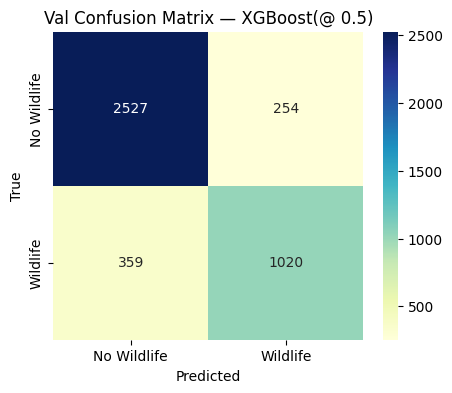

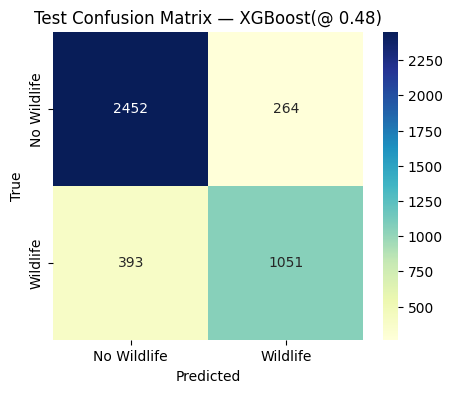

💾 Saved: /home/pratyush/Desktop/DS_Project/data/features/test_predictions_hog_color_glcm_lbp_pos.csv


In [2]:
# === Train & evaluate XGBoost on 5-feature combo, with threshold tuning ===
import os, numpy as np, pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt, seaborn as sns

FEATURE_DIR = "/home/pratyush/Desktop/DS_Project/data/features"
SUFFIX      = "hog_color_glcm_lbp_pos"

# Load
def load_feat(split):
    df = pd.read_csv(os.path.join(FEATURE_DIR, f"{split}_{SUFFIX}_features.csv"))
    X = df.drop(columns=["image","cell_id","label"]).values.astype(np.float32)
    y = df["label"].values.astype(int)
    meta = df[["image","cell_id"]].reset_index(drop=True)
    return X, y, meta

X_train, y_train, _     = load_feat("train")
X_val,   y_val,   metaV = load_feat("val")
X_test,  y_test,  metaT = load_feat("test")
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

# Model
xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.04,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.75,
    reg_lambda=1.0,
    min_child_weight=3,
    gamma=0.2,
    scale_pos_weight=2,       # imbalance
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)
print("\n🚀 Training XGBoost (5-feature combo)...")
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Validate (default 0.5 threshold)
p_val = xgb.predict_proba(X_val)[:,1]
y_val_pred_05 = (p_val >= 0.50).astype(int)
print(f"\n✅ Val Accuracy @0.50: {accuracy_score(y_val, y_val_pred_05):.4f}")
print("Val report @0.50:\n", classification_report(y_val, y_val_pred_05, digits=3))

# Threshold tuning (maximize F1 on val)
best_thr, best_f1 = 0.50, 0.0
for thr in np.linspace(0.30, 0.60, 31):   # sweep thresholds
    y_hat = (p_val >= thr).astype(int)
    f1 = f1_score(y_val, y_hat)
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

print(f"\n🎯 Best threshold on Val = {best_thr:.2f} (F1={best_f1:.3f})")

# Test using tuned threshold
p_test = xgb.predict_proba(X_test)[:,1]
y_test_pred = (p_test >= best_thr).astype(int)

print(f"\n🧪 Test Accuracy @thr={best_thr:.2f}: {accuracy_score(y_test, y_test_pred):.4f}")
print("Test report:\n", classification_report(y_test, y_test_pred, digits=3))

cm = confusion_matrix(y_val, y_val_pred_05)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['No Wildlife','Wildlife'],
            yticklabels=['No Wildlife','Wildlife'])
plt.title("Val Confusion Matrix — XGBoost(@ 0.5)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['No Wildlife','Wildlife'],
            yticklabels=['No Wildlife','Wildlife'])
plt.title("Test Confusion Matrix — XGBoost(@ 0.48)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# (Optional) save predictions with metadata
out_pred = metaT.copy()
out_pred["true"] = y_test
out_pred["prob"] = p_test
out_pred["pred"] = y_test_pred
out_pred.to_csv(os.path.join(FEATURE_DIR, f"test_predictions_{SUFFIX}.csv"), index=False)
print("💾 Saved:", os.path.join(FEATURE_DIR, f"test_predictions_{SUFFIX}.csv"))


# Generate CSV

In [8]:
# === Compact CSVs: only image, grid cell, true, predicted ===
import os, pandas as pd, numpy as np

OUT_DIR = os.path.abspath(os.path.join(FEATURE_DIR, "..", "results"))
os.makedirs(OUT_DIR, exist_ok=True)

def build_small_csv(split, model, thr):
    # Load full split to get labels + metadata
    df = pd.read_csv(os.path.join(FEATURE_DIR, f"{split}_{SUFFIX}_features.csv"))
    X = df.drop(columns=["image", "cell_id", "label"]).values.astype(np.float32)
    y_true = df["label"].values.astype(int)
    p = model.predict_proba(X)[:, 1]
    y_pred = (p >= thr).astype(int)

    out = pd.DataFrame({
        "image": df["image"],
        "cell_id": df["cell_id"],
        "actual_label": y_true,
        "predicted_label": y_pred
    })

    path = os.path.join(OUT_DIR, f"{split}_predictions_compact_{SUFFIX}.csv")
    out.to_csv(path, index=False)
    print(f"💾 Saved: {path}")
    out.insert(0, "split", split)
    return out

# Build & save all splits
df_train = build_small_csv("train", xgb, best_thr)
df_val   = build_small_csv("val",   xgb, best_thr)
df_test  = build_small_csv("test",  xgb, best_thr)

# Combine all splits into one compact CSV
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
combined_path = os.path.join(OUT_DIR, f"all_predictions_compact_{SUFFIX}.csv")
df_all.to_csv(combined_path, index=False)
print(f"📦 Combined compact CSV saved: {combined_path}")


💾 Saved: /home/pratyush/Desktop/DS_Project/data/results/train_predictions_compact_hog_color_glcm_lbp_pos.csv
💾 Saved: /home/pratyush/Desktop/DS_Project/data/results/val_predictions_compact_hog_color_glcm_lbp_pos.csv
💾 Saved: /home/pratyush/Desktop/DS_Project/data/results/test_predictions_compact_hog_color_glcm_lbp_pos.csv
📦 Combined compact CSV saved: /home/pratyush/Desktop/DS_Project/data/results/all_predictions_compact_hog_color_glcm_lbp_pos.csv


# Predicted output_csv on all(Train + val + test)

In [3]:
# === Generate predicted_all_splits.csv (image | c01..c64) in preprocessed order ===
import os, re, glob
import numpy as np
import pandas as pd

# -------- PATHS --------
BASE      = "/home/pratyush/Desktop/DS_Project"
PRE_DIR   = f"{BASE}/data/preprocessed"    # to order rows like original images
FEAT_DIR  = f"{BASE}/data/features"
OUT_PATH  = f"{BASE}/results/predicted_all_splits.csv"

# -------- SETTINGS --------
# Your trained model + threshold should already exist in the notebook:
#   xgb       -> fitted XGBoost model
#   best_thr  -> chosen decision threshold
# Fallbacks (won't override if already defined)
try:
    best_thr
except NameError:
    best_thr = 0.50  # safe default if not defined

# -------- UTIL: natural sort for filenames --------
_ns_re = re.compile(r'(\d+)')
def natural_key(s: str):
    return [int(t) if t.isdigit() else t.lower() for t in _ns_re.split(s)]

# -------- 1) Load & combine feature CSVs (train + val + test) --------
# Adjust patterns if your filenames differ
candidates = [
    f"{FEAT_DIR}/train_hog_color_glcm_lbp_pos_features.csv",
    f"{FEAT_DIR}/val_hog_color_glcm_lbp_pos_features.csv",
    f"{FEAT_DIR}/test_hog_color_glcm_lbp_pos_features.csv",
]

dfs = []
for p in candidates:
    if os.path.exists(p):
        dfs.append(pd.read_csv(p))
if not dfs:
    raise FileNotFoundError("No feature CSVs found. Check FEAT_DIR filenames.")

df_all = pd.concat(dfs, ignore_index=True)

# -------- 2) Predict on all rows --------
feature_cols = [c for c in df_all.columns if c not in ("image", "cell_id", "label")]
X_all = df_all[feature_cols].values.astype(np.float32)

# Guard against NaN/inf
if not np.isfinite(X_all).all():
    X_all = np.nan_to_num(X_all, nan=0.0, posinf=1e6, neginf=-1e6)

p_all = xgb.predict_proba(X_all)[:, 1]
df_all = df_all.copy()
df_all["pred"] = (p_all >= float(best_thr)).astype(int)

# -------- 3) Pivot to wide (image | c01..c64) --------
# Ensure cell ids like "c01".."c64"
df_all["cell_id"] = df_all["cell_id"].astype(str).str.lower()
df_all["cell_id"] = df_all["cell_id"].str.replace(r'^c(\d)$', r'c0\1', regex=True)  # pad single digits if needed

cols64 = [f"c{i:02d}" for i in range(1, 65)]
wide = (
    df_all.pivot_table(index="image", columns="cell_id", values="pred", aggfunc="first")
          .reindex(columns=cols64)
          .fillna(0)
          .astype(int)
          .reset_index()
)

# -------- 4) Reorder rows to match PRE_DIR image order --------
# Collect basenames (with extension) in natural order from preprocessed dir
img_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
img_files = []
for ext in img_exts:
    img_files.extend(glob.glob(os.path.join(PRE_DIR, ext)))
img_files = sorted(img_files, key=natural_key)
pre_names = [os.path.basename(p) for p in img_files]

# Keep only images present in our prediction table, in that order
present = set(wide["image"].tolist())
ordered_names = [n for n in pre_names if n in present]

# Add any remaining (in case some weren’t in PRE_DIR listing)
remaining = [n for n in wide["image"].tolist() if n not in set(ordered_names)]
row_order = ordered_names + remaining

wide = wide.set_index("image").loc[row_order].reset_index()

# -------- 5) Save --------
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
wide.to_csv(OUT_PATH, index=False)

print(f"✅ Saved: {OUT_PATH}")
print("Shape:", wide.shape)           # (num_images, 65)
print("Columns:", list(wide.columns)) # ['image','c01',...,'c64']


✅ Saved: /home/pratyush/Desktop/DS_Project/results/predicted_all_splits.csv
Shape: (431, 65)
Columns: ['image', 'c01', 'c02', 'c03', 'c04', 'c05', 'c06', 'c07', 'c08', 'c09', 'c10', 'c11', 'c12', 'c13', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'c22', 'c23', 'c24', 'c25', 'c26', 'c27', 'c28', 'c29', 'c30', 'c31', 'c32', 'c33', 'c34', 'c35', 'c36', 'c37', 'c38', 'c39', 'c40', 'c41', 'c42', 'c43', 'c44', 'c45', 'c46', 'c47', 'c48', 'c49', 'c50', 'c51', 'c52', 'c53', 'c54', 'c55', 'c56', 'c57', 'c58', 'c59', 'c60', 'c61', 'c62', 'c63', 'c64']


# Blur the predicted grid

In [4]:
# === Shade predicted cells (no blur) + draw grid & numbers ===
# Input CSV: image,c01..c64  (e.g., results/predicted_all_splits.csv)
# Images:    /home/pratyush/Desktop/DS_Project/data/preprocessed  (800x600)
# Output:    /home/pratyush/Desktop/DS_Project/data/after_grid_image

import os, cv2
import numpy as np
import pandas as pd

# -------- PATHS --------
BASE        = "/home/pratyush/Desktop/DS_Project"
PRE_DIR     = f"{BASE}/data/preprocessed"
CSV_PATH    = f"{BASE}/results/predicted_all_splits.csv"   # change if needed
OUT_DIR     = f"{BASE}/results/after_grid_image"
os.makedirs(OUT_DIR, exist_ok=True)

# -------- GRID PARAMS --------
W, H   = 800, 600
GW, GH = 8, 8
CW, CH = W // GW, H // GH  # 100x75

GRID_COLOR  = (0, 255, 255)  # yellow (BGR)
GRID_THICK  = 1
FONT        = cv2.FONT_HERSHEY_SIMPLEX
FSCALE      = 0.45
FTHICK      = 1
TEXT_COLOR  = (0, 255, 255)
TEXT_SHADOW = (0, 0, 0)

# -------- SHADING (no blur) --------
SHADE_COLOR = (0, 0, 0)  # black tint
ALPHA       = 0.35       # 0..1 (higher = darker)

# -------- LOAD PREDICTIONS --------
df = pd.read_csv(CSV_PATH)
cols64 = [f"c{i:02d}" for i in range(1, 65)]
if any(c not in df.columns for c in cols64):
    raise ValueError("CSV must have columns: image,c01..c64")

pred_map = {row["image"]: row[cols64].to_numpy(np.uint8) for _, row in df.iterrows()}

def ensure_size(img, w=W, h=H):
    if img is None:
        return None
    if img.shape[1] == w and img.shape[0] == h:
        return img
    return cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)

def draw_grid_and_numbers(img):
    # grid
    for x in range(0, W + 1, CW):
        cv2.line(img, (x, 0), (x, H), GRID_COLOR, GRID_THICK, lineType=cv2.LINE_AA)
    for y in range(0, H + 1, CH):
        cv2.line(img, (0, y), (W, y), GRID_COLOR, GRID_THICK, lineType=cv2.LINE_AA)
    # numbers bottom-left
    k = 1
    for r in range(GH):
        for c in range(GW):
            x0, y0 = c * CW, r * CH
            org = (x0 + 4, y0 + CH - 6)
            cv2.putText(img, str(k), org, FONT, FSCALE, TEXT_SHADOW, FTHICK + 1, cv2.LINE_AA)
            cv2.putText(img, str(k), org, FONT, FSCALE, TEXT_COLOR,  FTHICK,     cv2.LINE_AA)
            k += 1
    return img

count_ok, count_miss = 0, 0
for img_name, preds in pred_map.items():
    in_path  = os.path.join(PRE_DIR, img_name)
    out_path = os.path.join(OUT_DIR, img_name)

    img = cv2.imread(in_path, cv2.IMREAD_COLOR)
    if img is None:
        count_miss += 1
        continue
    img = ensure_size(img)

    out = img.copy()

    # Shade cells with prediction==1
    for idx, val in enumerate(preds, start=1):
        if val != 1:
            continue
        r = (idx - 1) // GW
        c = (idx - 1) %  GW
        x0, y0 = c * CW, r * CH
        x1, y1 = x0 + CW, y0 + CH

        roi = out[y0:y1, x0:x1]
        shade = np.full_like(roi, SHADE_COLOR, dtype=np.uint8)
        # alpha blend: out = (1-ALPHA)*roi + ALPHA*shade_color
        cv2.addWeighted(shade, ALPHA, roi, 1.0 - ALPHA, 0, dst=roi)

    # Grid + numbers on top
    draw_grid_and_numbers(out)

    cv2.imwrite(out_path, out)
    count_ok += 1

print(f"✅ Saved {count_ok} images to {OUT_DIR}")
if count_miss:
    print(f"⚠️ {count_miss} images were listed in CSV but not found in preprocessed folder.")


✅ Saved 431 images to /home/pratyush/Desktop/DS_Project/results/after_grid_image


# Pickel Model

In [5]:
import pickle

# Save the trained XGBoost model
with open("best_model.pkl", "wb") as f:
    pickle.dump(xgb, f, protocol=4)

print("✅ Model saved as best_model.pkl using Pickle Protocol 4")


✅ Model saved as best_model.pkl using Pickle Protocol 4


# Reload

In [6]:
import pickle
with open("best_model.pkl", "rb") as f:
    xgb_loaded = pickle.load(f)

print(xgb_loaded)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.75, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.04, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)
